# Credit-Card Fraud Detection on Highly Imbalanced Data


Fraud detection is a textbook *extreme class-imbalance* problem: in the public ULB
credit-card dataset only **0.17%** of transactions are fraudulent. That rarity breaks
the usual machine-learning reflexes:

- **Accuracy is a trap.** A model that predicts *"never fraud"* scores **99.83% accuracy**
  while catching exactly zero criminals.
- **Naive resampling leaks.** The most common fix — SMOTE oversampling — is frequently applied
  *before* the train/test split, which lets synthetic copies of test points appear in training
  and produces beautiful-but-fake metrics.

### What this notebook does differently

I analysed two existing repositories, which led me to implementing this on my own. My implementation does the following:

1. **Demonstrate the leakage** — reproduce the inflated ~0.99 scores, then show what honest numbers look like.
2. **Handle imbalance correctly** — cost-sensitive learning (`class_weight` / `scale_pos_weight`)
   and SMOTE applied *strictly inside cross-validation folds*.
3. **Use the right metrics** — Precision-Recall AUC (PR-AUC / Average Precision) instead of accuracy.
4. **Tune the decision threshold to a business cost** rather than blindly using 0.5.
5. **Compare four models** — Logistic Regression, Random Forest, XGBoost, and an unsupervised Isolation Forest.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_recall_curve,
                             roc_curve, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
print("Environment ready.")

Environment ready.


## 2. Load the data

The ULB *Credit Card Fraud Detection* dataset (Worldline & ULB, 2013). Features `V1`–`V28`
are anonymised **PCA components**, `Amount` is the transaction value, and `Class` is the
target (1 = fraud). Because the features are already PCA outputs they are mutually
decorrelated and pre-scaled — only `Amount` needs scaling.

> Reproducible fetch: the CSV in `data/` was produced once via
> `sklearn.datasets.fetch_openml("creditcard", version=1)` — no Kaggle login required.

In [2]:
df = pd.read_csv("data/creditcard.csv")
print("Shape:", df.shape)
df.head()

Shape: (284807, 30)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
n = len(df)
n_fraud = int(df["Class"].sum())
print(f"Transactions   : {n:,}")
print(f"Fraudulent     : {n_fraud:,}  ({100*n_fraud/n:.3f}%)")
print(f"Legitimate     : {n-n_fraud:,}  ({100*(n-n_fraud)/n:.3f}%)")
print(f"Missing values : {int(df.isnull().sum().sum())}")
print(f"Imbalance ratio: ~1 fraud for every {round((n-n_fraud)/n_fraud):,} legit transactions")

Transactions   : 284,807
Fraudulent     : 492  (0.173%)
Legitimate     : 284,315  (99.827%)
Missing values : 0
Imbalance ratio: ~1 fraud for every 578 legit transactions


## 3. Exploratory data analysis

### 3.1 Just how imbalanced is it?

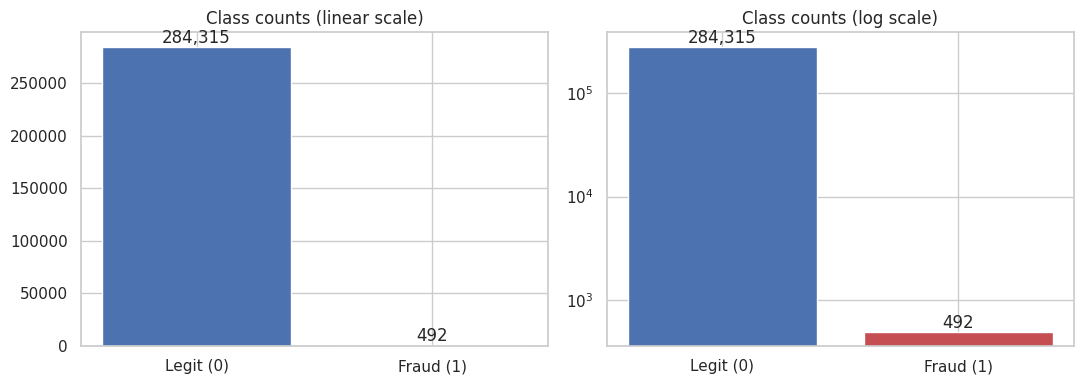

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
counts = df["Class"].value_counts().sort_index()
for a, logscale in [(ax[0], False), (ax[1], True)]:
    a.bar(["Legit (0)", "Fraud (1)"], counts.values, color=["#4C72B0", "#C44E52"])
    if logscale:
        a.set_yscale("log"); a.set_title("Class counts (log scale)")
    else:
        a.set_title("Class counts (linear scale)")
    for i, v in enumerate(counts.values):
        a.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

### 3.2 Does transaction `Amount` separate the classes?

/tmp/ipykernel_32107/2324526543.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(["Legit", "Fraud"])


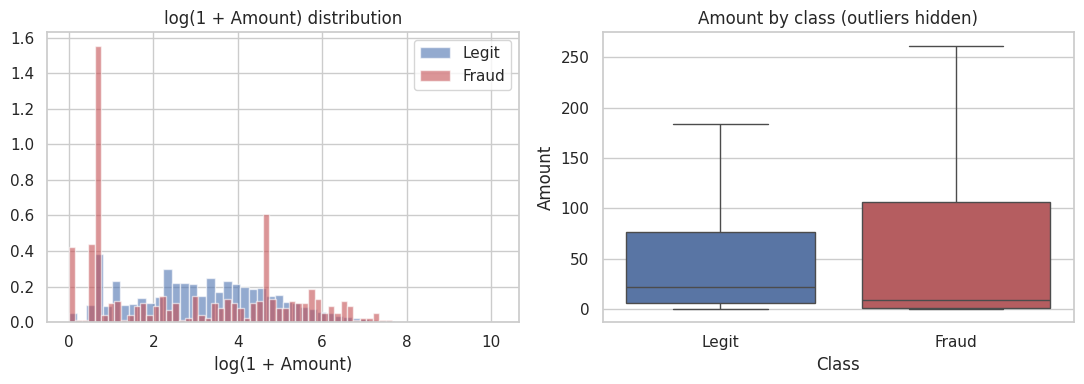

         mean  median       max
Class                          
0       88.29   22.00  25691.16
1      122.21    9.25   2125.87


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for c, color, label in [(0, "#4C72B0", "Legit"), (1, "#C44E52", "Fraud")]:
    ax[0].hist(np.log1p(df.loc[df.Class == c, "Amount"]), bins=50, alpha=0.6,
               color=color, density=True, label=label)
ax[0].set_title("log(1 + Amount) distribution"); ax[0].set_xlabel("log(1 + Amount)"); ax[0].legend()
sns.boxplot(data=df, x="Class", y="Amount", hue="Class", legend=False,
            showfliers=False, palette=["#4C72B0", "#C44E52"], ax=ax[1])
ax[1].set_title("Amount by class (outliers hidden)")
ax[1].set_xticklabels(["Legit", "Fraud"])
plt.tight_layout(); plt.show()
print(df.groupby("Class")["Amount"].agg(["mean", "median", "max"]).round(2))

### 3.3 Which features carry the fraud signal?

Since `V1`–`V28` are PCA components they barely correlate *with each other*, so a full
correlation heatmap is mostly noise. More useful: how strongly each feature correlates
**with the target**.

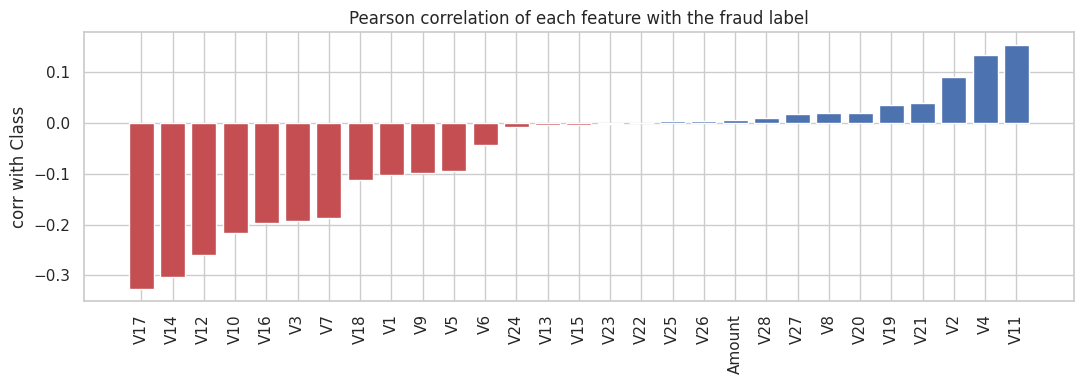

Top features by |correlation| with fraud: ['V17', 'V14', 'V12', 'V10']


In [6]:
corr_target = df.corr(numeric_only=True)["Class"].drop("Class").sort_values()
fig, ax = plt.subplots(figsize=(11, 4))
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in corr_target.values]
ax.bar(range(len(corr_target)), corr_target.values, color=colors)
ax.set_xticks(range(len(corr_target)))
ax.set_xticklabels(corr_target.index, rotation=90)
ax.set_title("Pearson correlation of each feature with the fraud label")
ax.set_ylabel("corr with Class")
plt.tight_layout(); plt.show()
top_feats = corr_target.abs().sort_values(ascending=False).head(4).index.tolist()
print("Top features by |correlation| with fraud:", top_feats)

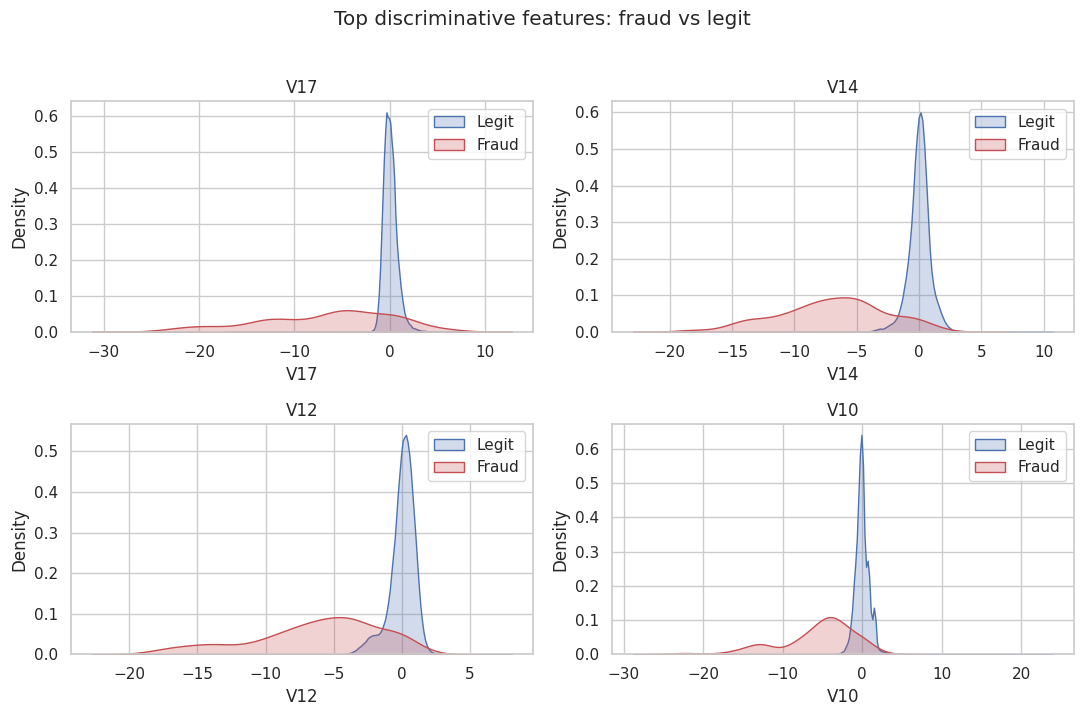

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, f in zip(axes.ravel(), top_feats):
    sns.kdeplot(df.loc[df.Class == 0, f], ax=ax, fill=True, color="#4C72B0",
                label="Legit", warn_singular=False)
    sns.kdeplot(df.loc[df.Class == 1, f], ax=ax, fill=True, color="#C44E52",
                label="Fraud", warn_singular=False)
    ax.set_title(f"{f}"); ax.legend()
plt.suptitle("Top discriminative features: fraud vs legit", y=1.02)
plt.tight_layout(); plt.show()

## 4. The leakage trap (reproducing the inflated scores)

The problem: SMOTE creates synthetic minority points by interpolating between
real neighbours. After a random split, a test point can be the interpolation of two points
now sitting in the training set — the model has effectively *seen the answer*. The test set
also becomes an artificial 50/50 balance that no longer resembles reality.

Let's reproduce it and watch the metrics balloon.

In [8]:
X_all = df.drop(columns="Class").values
y_all = df["Class"].values

# WRONG ORDER: oversample first, split second
X_res, y_res = SMOTE(random_state=RANDOM_STATE).fit_resample(X_all, y_all)
Xtr_l, Xte_l, ytr_l, yte_l = train_test_split(
    X_res, y_res, test_size=0.2, stratify=y_res, random_state=RANDOM_STATE)

leak = LogisticRegression(max_iter=1000)
leak.fit(Xtr_l, ytr_l)
p_leak = leak.predict_proba(Xte_l)[:, 1]
pred_leak = (p_leak >= 0.5).astype(int)
print("LEAKY pipeline  (SMOTE applied BEFORE the split)")
print(f"  Test set      : {len(yte_l):,} rows, {100*yte_l.mean():.1f}% fraud (synthetically balanced!)")
print(f"  ROC-AUC       : {roc_auc_score(yte_l, p_leak):.4f}")
print(f"  PR-AUC        : {average_precision_score(yte_l, p_leak):.4f}")
print(f"  Recall        : {recall_score(yte_l, pred_leak):.4f}")
print(f"  Accuracy      : {(pred_leak == yte_l).mean():.4f}")
print("\n  --> a plain logistic regression looks near-perfect. It is an illusion.")

LEAKY pipeline  (SMOTE applied BEFORE the split)
  Test set      : 113,726 rows, 50.0% fraud (synthetically balanced!)
  ROC-AUC       : 0.9921
  PR-AUC        : 0.9933
  Recall        : 0.9373
  Accuracy      : 0.9594

  --> a plain logistic regression looks near-perfect. It is an illusion.


## 5. An honest experimental setup

The fix is simple and non-negotiable: **split first, resample only the training data.**

- Stratified 80/20 split so the test set keeps the real 0.17% fraud rate.
- Scale `Amount` only, fitting the scaler on the **training set** and applying it to test.
- The test set is never touched by any resampling.

In [9]:
X = df.drop(columns="Class").copy()
y = df["Class"].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train = X_train.copy(); X_test = X_test.copy()
X_train["Amount"] = scaler.fit_transform(X_train[["Amount"]])
X_test["Amount"]  = scaler.transform(X_test[["Amount"]])

print(f"Train: {X_train.shape[0]:,} rows, {int(y_train.sum())} frauds "
      f"({100*y_train.mean():.3f}%)")
print(f"Test : {X_test.shape[0]:,} rows, {int(y_test.sum())} frauds "
      f"({100*y_test.mean():.3f}%)")

Train: 227,845 rows, 394 frauds (0.173%)
Test : 56,962 rows, 98 frauds (0.172%)


### A shared evaluation helper

Every model is judged on the **same untouched, imbalanced test set**, and the headline
metric is **PR-AUC (Average Precision)** — the area under the precision-recall curve, which
is the meaningful summary when the positive class is rare.

In [10]:
results = {}
def evaluate(name, scores, y_true=y_test, threshold=0.5, store=True):
    preds = (scores >= threshold).astype(int)
    row = dict(
        pr_auc=average_precision_score(y_true, scores),
        roc_auc=roc_auc_score(y_true, scores),
        precision=precision_score(y_true, preds, zero_division=0),
        recall=recall_score(y_true, preds, zero_division=0),
        f1=f1_score(y_true, preds, zero_division=0),
    )
    if store:
        results[name] = row
    print(f"{name}")
    print(f"  PR-AUC={row['pr_auc']:.4f}  ROC-AUC={row['roc_auc']:.4f}  "
          f"P={row['precision']:.3f}  R={row['recall']:.3f}  F1={row['f1']:.3f}")
    return scores

## 6. Cost-sensitive models (no resampling)

Instead of inventing synthetic data, we tell each model that mistakes on the rare class
are expensive. For linear/tree models that is `class_weight="balanced"`; for XGBoost it is
`scale_pos_weight` = (#negatives / #positives).

In [11]:
logreg = LogisticRegression(max_iter=1000, class_weight="balanced",
                            random_state=RANDOM_STATE)
logreg.fit(X_train, y_train)
_ = evaluate("LogReg (class_weight)", logreg.predict_proba(X_test)[:, 1])

LogReg (class_weight)
  PR-AUC=0.7199  ROC-AUC=0.9714  P=0.059  R=0.918  F1=0.111


In [12]:
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced_subsample",
                            n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
_ = evaluate("RandomForest (class_weight)", rf.predict_proba(X_test)[:, 1])

RandomForest (class_weight)
  PR-AUC=0.8584  ROC-AUC=0.9521  P=0.961  R=0.755  F1=0.846


In [13]:
spw = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.1,
                    subsample=0.9, colsample_bytree=0.9, scale_pos_weight=spw,
                    eval_metric="aucpr", n_jobs=-1, random_state=RANDOM_STATE)
xgb.fit(X_train, y_train)
xgb_scores = evaluate("XGBoost (scale_pos_weight)", xgb.predict_proba(X_test)[:, 1])
print(f"\nscale_pos_weight = {spw:.1f}")

XGBoost (scale_pos_weight)
  PR-AUC=0.8787  ROC-AUC=0.9760  P=0.854  R=0.837  F1=0.845

scale_pos_weight = 577.3


## 7. SMOTE done *right* (inside cross-validation)

SMOTE is not inherently bad — it just has to live **inside** the cross-validation loop so it
only ever sees training folds. `imblearn`'s `Pipeline` guarantees this: in each fold SMOTE
fits on the training portion, and the held-out portion stays real.

Notice the honest PR-AUC lands in the same ballpark as cost-sensitive learning — nowhere
near the fake 0.98 from Section 4.

In [14]:
pipe = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_res = cross_validate(pipe, X_train, y_train, cv=cv,
                        scoring=["average_precision", "roc_auc"], n_jobs=-1)
print("SMOTE-inside-CV LogReg (no leakage), 5-fold on training data:")
print(f"  PR-AUC : {cv_res['test_average_precision'].mean():.4f} "
      f"+/- {cv_res['test_average_precision'].std():.4f}")
print(f"  ROC-AUC: {cv_res['test_roc_auc'].mean():.4f} "
      f"+/- {cv_res['test_roc_auc'].std():.4f}")

pipe.fit(X_train, y_train)
_ = evaluate("LogReg + SMOTE (correct)", pipe.predict_proba(X_test)[:, 1])

SMOTE-inside-CV LogReg (no leakage), 5-fold on training data:
  PR-AUC : 0.7519 +/- 0.0497
  ROC-AUC: 0.9804 +/- 0.0127


LogReg + SMOTE (correct)
  PR-AUC=0.7229  ROC-AUC=0.9700  P=0.056  R=0.918  F1=0.105


## 8. Model comparison (honest, on the imbalanced test set)

                             pr_auc  roc_auc  precision  recall      f1
XGBoost (scale_pos_weight)   0.8787   0.9760     0.8542  0.8367  0.8454
RandomForest (class_weight)  0.8584   0.9521     0.9610  0.7551  0.8457
LogReg + SMOTE (correct)     0.7229   0.9700     0.0558  0.9184  0.1053
LogReg (class_weight)        0.7199   0.9714     0.0589  0.9184  0.1106


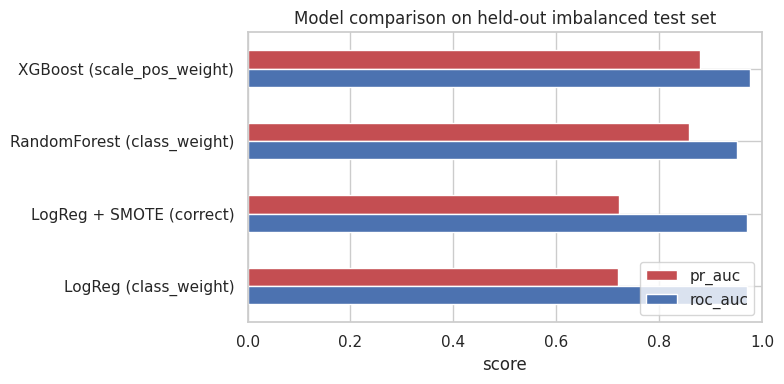

In [15]:
comp = (pd.DataFrame(results).T[["pr_auc", "roc_auc", "precision", "recall", "f1"]]
          .sort_values("pr_auc", ascending=False))
print(comp.round(4).to_string())

ax = comp[["pr_auc", "roc_auc"]].plot(kind="barh", figsize=(8, 4),
                                      color=["#C44E52", "#4C72B0"])
ax.invert_yaxis(); ax.set_xlabel("score"); ax.set_xlim(0, 1)
ax.set_title("Model comparison on held-out imbalanced test set")
plt.tight_layout(); plt.show()

XGBoost (and Random Forest) clearly win on PR-AUC. Note how **ROC-AUC looks great for every
model (~0.95+)** even when PR-AUC is mediocre — another reminder that on imbalanced data
ROC-AUC is over-optimistic and PR-AUC is the metric to trust.

## 9. Precision-Recall and ROC curves for the best model (XGBoost)

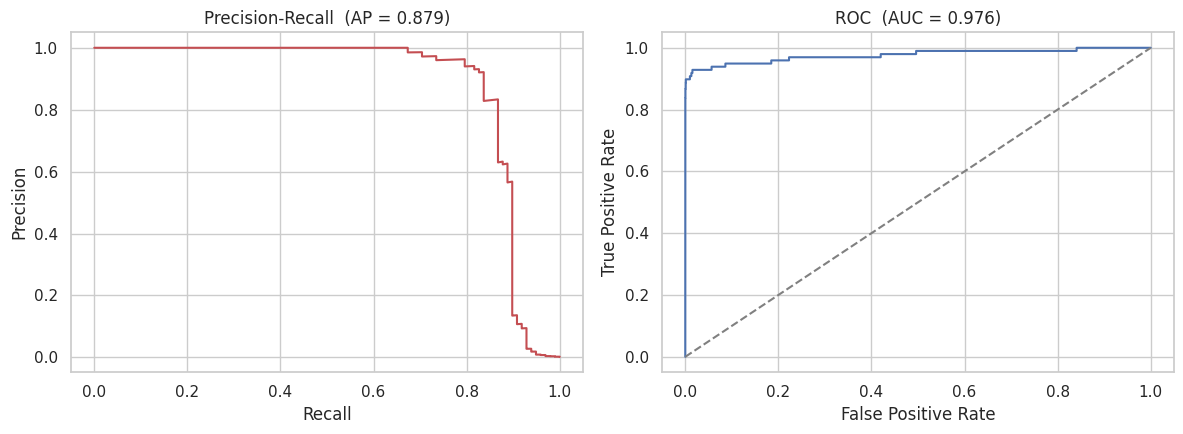

In [16]:
prec, rec, _ = precision_recall_curve(y_test, xgb_scores)
fpr, tpr, _ = roc_curve(y_test, xgb_scores)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(rec, prec, color="#C44E52")
ax[0].set_xlabel("Recall"); ax[0].set_ylabel("Precision")
ax[0].set_title(f"Precision-Recall  (AP = {average_precision_score(y_test, xgb_scores):.3f})")
ax[1].plot(fpr, tpr, color="#4C72B0"); ax[1].plot([0, 1], [0, 1], "--", color="gray")
ax[1].set_xlabel("False Positive Rate"); ax[1].set_ylabel("True Positive Rate")
ax[1].set_title(f"ROC  (AUC = {roc_auc_score(y_test, xgb_scores):.3f})")
plt.tight_layout(); plt.show()

## 10. Choosing a threshold that matches the business cost

The default 0.5 cut-off is arbitrary. In fraud, a **missed fraud (false negative)** is far
more expensive than a **false alarm (false positive)** that merely triggers a review. We
encode that as a cost ratio and pick the threshold that minimises expected cost.

Cost-optimal threshold = 0.006   (C_FN=100, C_FP=1)


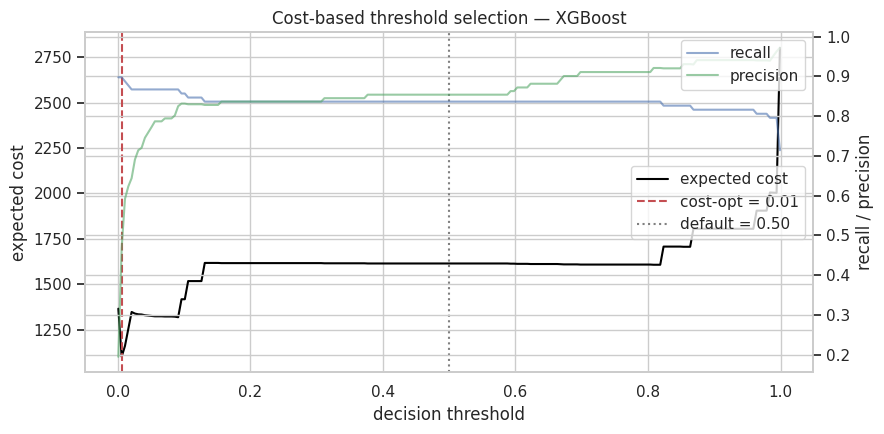

In [17]:
C_FN, C_FP = 100.0, 1.0   # a missed fraud costs ~100x a false alarm
thr_grid = np.linspace(0.001, 0.999, 200)
costs, recalls, precisions = [], [], []
for t in thr_grid:
    tn, fp, fn, tp = confusion_matrix(y_test, (xgb_scores >= t).astype(int)).ravel()
    costs.append(C_FN * fn + C_FP * fp)
    recalls.append(tp / (tp + fn))
    precisions.append(tp / (tp + fp) if (tp + fp) else 0.0)
costs = np.array(costs)
best_t = float(thr_grid[costs.argmin()])
print(f"Cost-optimal threshold = {best_t:.3f}   (C_FN={C_FN:.0f}, C_FP={C_FP:.0f})")

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(thr_grid, costs, color="black", label="expected cost")
ax1.axvline(best_t, color="#C44E52", ls="--", label=f"cost-opt = {best_t:.2f}")
ax1.axvline(0.5, color="gray", ls=":", label="default = 0.50")
ax1.set_xlabel("decision threshold"); ax1.set_ylabel("expected cost")
ax2 = ax1.twinx()
ax2.plot(thr_grid, recalls, color="#4C72B0", alpha=0.6, label="recall")
ax2.plot(thr_grid, precisions, color="#55A868", alpha=0.6, label="precision")
ax2.set_ylabel("recall / precision")
ax1.legend(loc="center right"); ax2.legend(loc="upper right")
plt.title("Cost-based threshold selection — XGBoost")
plt.tight_layout(); plt.show()

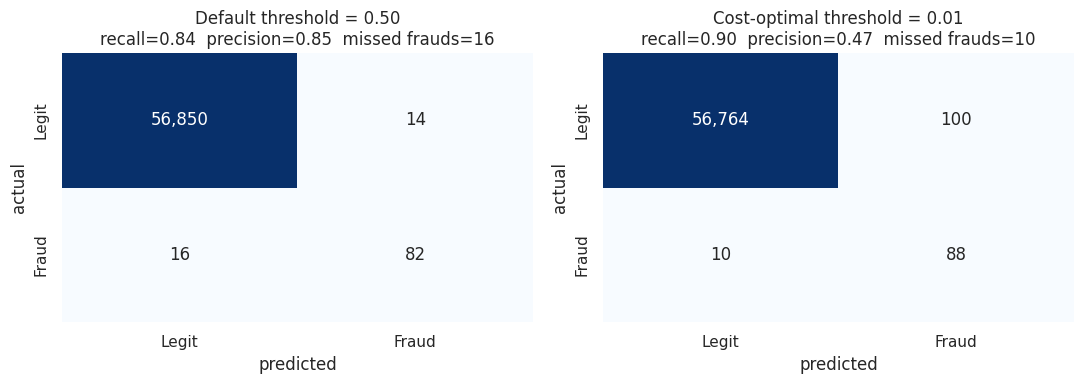

=== Default threshold 0.50 ===
              precision    recall  f1-score   support

       Legit     0.9997    0.9998    0.9997     56864
       Fraud     0.8542    0.8367    0.8454        98

    accuracy                         0.9995     56962
   macro avg     0.9269    0.9182    0.9225     56962
weighted avg     0.9995    0.9995    0.9995     56962

=== Cost-optimal threshold ===
              precision    recall  f1-score   support

       Legit     0.9998    0.9982    0.9990     56864
       Fraud     0.4681    0.8980    0.6154        98

    accuracy                         0.9981     56962
   macro avg     0.7340    0.9481    0.8072     56962
weighted avg     0.9989    0.9981    0.9984     56962



In [18]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, t, title in [(ax[0], 0.5, "Default threshold = 0.50"),
                    (ax[1], best_t, f"Cost-optimal threshold = {best_t:.2f}")]:
    cm = confusion_matrix(y_test, (xgb_scores >= t).astype(int))
    tn, fp, fn, tp = cm.ravel()
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=a,
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    a.set_title(f"{title}\nrecall={tp/(tp+fn):.2f}  precision={tp/(tp+fp):.2f}  "
                f"missed frauds={fn}")
    a.set_xlabel("predicted"); a.set_ylabel("actual")
plt.tight_layout(); plt.show()

print("=== Default threshold 0.50 ===")
print(classification_report(y_test, (xgb_scores >= 0.5).astype(int),
                            digits=4, target_names=["Legit", "Fraud"]))
print("=== Cost-optimal threshold ===")
print(classification_report(y_test, (xgb_scores >= best_t).astype(int),
                            digits=4, target_names=["Legit", "Fraud"]))

## 11. What is the model looking at? (feature importance)

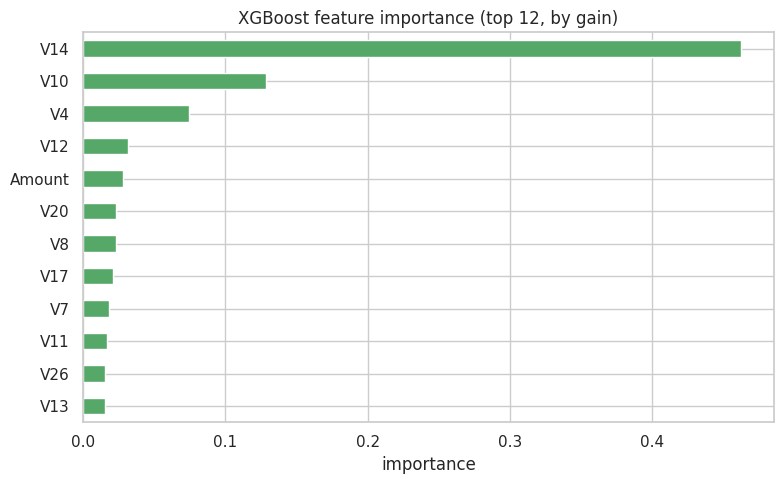

In [19]:
imp = (pd.Series(xgb.feature_importances_, index=X_train.columns)
         .sort_values(ascending=False).head(12))
ax = imp[::-1].plot(kind="barh", figsize=(8, 5), color="#55A868")
ax.set_title("XGBoost feature importance (top 12, by gain)")
ax.set_xlabel("importance")
plt.tight_layout(); plt.show()

## 12. An unsupervised contrast: Isolation Forest

Supervised models need labels. In production, labelled fraud often arrives late. As a
contrast we train an **Isolation Forest** on *legitimate transactions only* and treat
hard-to-isolate-from-normal points as anomalies — no fraud labels used in training.

In [20]:
iso = IsolationForest(n_estimators=200, contamination=float(y_train.mean()),
                      random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(X_train[y_train == 0])              # learn "normal" only
iso_scores = -iso.score_samples(X_test)     # higher = more anomalous
print("Isolation Forest (unsupervised, trained on legit transactions only):")
print(f"  PR-AUC : {average_precision_score(y_test, iso_scores):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, iso_scores):.4f}")
results["IsolationForest (unsup.)"] = dict(
    pr_auc=average_precision_score(y_test, iso_scores),
    roc_auc=roc_auc_score(y_test, iso_scores),
    precision=np.nan, recall=np.nan, f1=np.nan)

Isolation Forest (unsupervised, trained on legit transactions only):
  PR-AUC : 0.1373
  ROC-AUC: 0.9537


## 13. Final scoreboard & takeaways

In [21]:
final = (pd.DataFrame(results).T[["pr_auc", "roc_auc", "precision", "recall", "f1"]]
           .sort_values("pr_auc", ascending=False))
print(final.round(4).to_string())

                             pr_auc  roc_auc  precision  recall      f1
XGBoost (scale_pos_weight)   0.8787   0.9760     0.8542  0.8367  0.8454
RandomForest (class_weight)  0.8584   0.9521     0.9610  0.7551  0.8457
LogReg + SMOTE (correct)     0.7229   0.9700     0.0558  0.9184  0.1053
LogReg (class_weight)        0.7199   0.9714     0.0589  0.9184  0.1106
IsolationForest (unsup.)     0.1373   0.9537        NaN     NaN     NaN


### Takeaways

1. **The leaky-SMOTE result (~0.98–0.99 on everything) is not real.** Reproduced in Section 4
   and contrasted with honest numbers in Sections 6–8. Order of operations decides whether
   your evaluation means anything.
2. **PR-AUC, not accuracy or ROC-AUC, is the metric for rare-event detection.** Every model
   here scores ROC-AUC ~0.95+, but PR-AUC tells them apart and reflects real-world usefulness.
3. **Gradient boosting (XGBoost) with `scale_pos_weight` is the strongest supervised model**,
   edging out Random Forest; both beat logistic regression. Honest SMOTE roughly matches
   cost-sensitive learning — it is a valid alternative, not a magic boost.
4. **The decision threshold is a business lever, not a constant.** Tuning it to a 100:1
   fraud-cost ratio trades a little precision for materially higher recall (fewer missed frauds).
5. **Unsupervised Isolation Forest** is far weaker than the supervised models but needs no
   labels — useful as a cold-start or second-line detector.


### Possible next steps
Hyperparameter search, probability calibration, SHAP explanations for investigator-facing
reason codes, and time-aware validation (train on past, test on future) to mirror deployment.